# 17 The winding thermometer, calibrated

Whether the motor's own winding can be its thermometer turns on one number, the temperature
coefficient. A night at rest moves the can by a couple of degrees, and a heat run puts the winding
far above the can, so neither says how much R changes per degree on this motor, or whether part of
R does not change at all.

So I put the MG90 in a filament dryer with a thermocouple bead on its can, held it at room, 42 C and
60 C, and ran ten `osc ident burst` runs at each. Then I read the winding's DC resistance with a meter
twice, once hot and once at room. The meter has no burst, no fit and no switching in it, so it is the
outside reference for the slope.

The target is the one the plan set, the winding temperature to 5 C from R alone. Copper moves about
0.39% per C, so 5 C is about 2% of R. The questions were:

1. Does R follow copper on this motor, or is part of it fixed (brushes, leads)?
2. How precisely does one burst run read R, in degrees?
3. What moves R that is not temperature, and what does the firmware have to do about it?

The thermometer's slope is not up for fitting. Copper's coefficient is a handbook number, and
the DC pair is here to confirm that this motor's loop is copper and to bound any part of it that
is not. What the bursts do with that slope is a separate question about the burst estimator.

If you are short on time, here is the whole answer up front:

- **The winding loop is copper, so the thermometer runs on copper's handbook slope.** Copper's
  resistance is proportional to $(234.5 + T)$, 0.393% per C at 20 C. The two DC readings, 4.52 ohm
  at 28.6 C and 5.09 ohm at 61.5 C, are in the ratio 1.1261 where copper says 1.1250. Taken at face
  value they give 0.396 %/C, 101% of copper. The hot reading's winding temperature is only known to
  a bracket, 59.5 to 62.3 C, because the dryer was coming off temperature and the log has a gap, and
  across it the pair reads 98 to 108% of copper with a fixed, non-copper part of at most about
  0.1 ohm, 2% of R. That is a confirmation, not a calibration constant.
- **The bursts may scale with R a little less than the meter does.** The waveform-fit R that
  `osc ident` prints, through the last room set and both 60 C sets, climbs 0.365 +/- 0.022 %/C, 93%
  of copper and 1.3 standard errors under it. Its ratio to the DC reading is 1.049 at room and 1.040
  hot, a fall of 0.9 +/- 0.7%. Two quieter routes, the same fit with its R-V0 trade projected out
  and a period-average estimator, both fall 1.4 to 1.5 +/- 0.3%, but each leans on a
  temperature-correlated choice of the same size (section 6), so they do not settle it. What the data supports is a
  compression of the burst's R scale of 0 to 2% over 33 C. Uncorrected, 1.4% reads a 60 C winding as
  56 C from a room reference. Open has the test that would pin it.
- **The first two sets read 3 to 4% high.** The room set at 14:49 and the 42 C set at 15:43 sit 3.2%
  and 4.3% over the line, 8 and 12 C of copper. The cal and polarity-test bursts before them show the
  same excess. After an hour at 60 C it is gone, and it does not come back at room. It is flat inside
  each set, so it is not a winding still warm from the cal, and the second 60 C set reads where the
  first does, so it is not the rotor trailing the can either. Every single capture moved up together,
  so it is not a change in which rotor angles the bursts caught, and a binding gear train would move
  the fit the other way. What is left is a contact in series with the winding, at the brushes and
  commutator or at the J4 connector that was re-plugged that morning, that relaxed with the heat or
  with the hours. Nothing here separates those.
- **The thermometer is $T = T_{ref} + (R/R_{ref} - 1)(234.5 + T_{ref})$** on the waveform-fit R,
  with no fitted slope. One run scatters 1.76%, 4.6 C at room, and the mean of ten 0.56%, 1.5 C.
  With the R-V0 trade projected out, one run is 0.68%, 1.8 C. From a room reference the 60 C sets
  read 1.5 and 3.2 C low. So it meets the 5 C target as long as $R_{ref}$ is fresh, with the
  compression taking up to 4 C of it at 60 C if it is as large as the quieter routes say.
- **The rule that follows.** Re-baseline $R_{ref}$ at rest, at a known temperature, at power-up after
  an hour or more idle, and after any cal, stall or rebuild. A 4% contact shift reads as 10 C.


## Picking a rig

One dataset, `mg90-a__dev-v006-2A__dps__r-vs-t`. Its burst captures carry no `sense` block, so the board cannot be read off the data. The bench log says rev 2A board #1, so I name
it here, and the table below is what that choice means. The supply is the DPS-150, not the 2S pack.

In [1]:
import datetime as dt

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats
from IPython.display import display

import oscnb
from oscnb import boards, datasets, servos, rtsoak as rs, thermal as th

DS = datasets.load("mg90-a__dev-v006-2A__dps__r-vs-t")
# The burst captures carry no sense block, so the board cannot be read off the data. The bench
# log names it: rev 2A board #1.
board, servo = boards.BOARDS["dev-v006-2A"], servos.SERVOS["mg90-a"]
rig = oscnb.Rig(board, servo).show()

K_CU = th.T0_CU                                # copper: R is proportional to (234.5 + T in C), oscnb.thermal
cu_pct = th.copper_pct_per_c                   # copper's coefficient at t, in % of R(t) per C
PDT = dt.timezone(dt.timedelta(hours=-7))      # the bench clock, US Pacific daylight time
T_REF = 28.6                                   # the room DC reading's can temperature, the reference below


def to_ref(r, t, t_ref=T_REF):
    """R read at t, carried to t_ref along copper."""
    return th.copper_carry(r, t, t_ref)


def clock(u):
    return dt.datetime.fromtimestamp(float(u), PDT)


PL, EX, DC = rs.plateaus(DS), rs.extras(DS), rs.dc(DS)
LOG = rs.can_log(DS)
print(f"thermocouple: {len(LOG)} readings, {LOG.glitch.sum()} set aside as link glitches "
      f"({', '.join(f'{c:.1f}' for c in LOG.can_c[LOG.glitch])} C)")
LOG = LOG[~LOG.glitch]
RUNS = rs.runs(DS)                             # every plateau run, can_tc = the thermocouple at its start

Vorpal MG90 clone, unit A on osc-dev-v006 rev 2A, board #1

  board: Rs1 60 mOhm; bare OPA with Rf 6k4 / Rg 430 (G 14.884), Cc 22 pF, Co1 DNP. Terminal taps Rv1/Rv3 6k4 over Rv2/Rv4 1k6 with Cv1/Cv2 100 pF, bottoms and caps returned to VB from Rb1 430 / Rb2 100 (773 counts nominal, about 81 ohm source, so VB rises with the leg current under drive). VSNS 6k4/1k6 to GND, unbiased, Cv3 100 pF. A 2A capture's sense block differs from board D's in gain_milli and both divider legs. Nothing in the block carries the bias or VSNS parts, or which 2A unit took the capture, so every 2A board shares this entry. Board #1 had Rv3 open for the grid-3r7 2S session: in that dataset tap B reads the VB node instead of terminal B, so only tap A, the rail and the current are graded there. Rv3 is repaired, and a dataset captured with it fitted reads both taps. Floors 64/93 ticks: the current at 3% with the settle gain on top (nb10 sec 8), the terminals from the grid ladder with tap B sampled 37 ticks before 

value
where            quantity                                           unit                          
board            converter step                                     mV per count            0.8057
                 terminal divider ratio r                                                   5.0000
                 terminal difference                                mV per count            4.0283
                 terminal bias VB                                   mV                    622.6415
                                                                    counts                772.8302
                 driven-low terminal reads                          counts                618.2642
                 motor current                                      mA per count            0.9022
                                                                    counts per A         1108.4521
                 shunt                                              mOhm                   60.0000
                 amplifier gain                                     x                      14.8840
                 rail tap ratio                                                             5.0000
                 sample rate                                        samples per ms         20.0000
                 current settled from                               % duty                  5.3333
                 voltage settled from                               % duty                  7.7500
servo            pot intercept                                      counts                209.0000
                 pot slope                                          counts per degree      19.7600
                 envelope low                                       counts (15.74 deg)    520.0224
                 envelope high                                      counts (168.59 deg)  3540.3384
                 runway                                             counts               3020.3160
                 seek guard low                                     counts                520.0000
                 seek guard high                                    counts               3540.0000
servo (measured) gear_ratio_measured [308.053, 308.053] mechanic... :1                    308.0533
                 ripple_order_measured [6, 6] teardown, 3-slot b... per motor rev           6.0000
                 r_winding_measured [4.49, 4.98] bringup capture... Ohm                     4.8900
                 ke_ripple_measured [1.284, 1.306] nb09 sec 3, s... mV per ripple Hz        1.2950
                 pot_scale_measured [19.7, 19.85] nb09 sec 10, r... counts/deg             19.7600
                 travel_measured [178.67, 189.18] nb09 sec 10, p... deg                   184.2200
                 low_stop_after_stall_measured [232, 236] hand s... counts                232.0000
                 backlash_measured [1.25, 1.5] nb09 sec 4, rever... ripple cycles           1.4800

thermocouple: 2322 readings, 9 set aside as link glitches (132.4, 106.8, 2.2, 47.9, 123.7, 74.7, 43.6, 118.6, 43.8 C)


## 1. The experiment

- **Procedure.** The MG90 (the TowerPro clone sold by Vorpal) sits in a SUNLU filament dryer with
  the horn off and the rotor free. The board sits outside the dryer at room, fed by a DPS-150 bench supply at
  7.9 V on its battery wires. A K thermocouple bead is taped to the motor can and read by the B41T+ meter
  over Bluetooth every 5 s. At each of five plateaus (room, 42 C, 60 C, 60 C again, room) the soak
  script runs ten `osc ident burst` runs at mid travel about 65 s apart, alternating the driven tap
  only (`p1`) and both taps (`p1diff`), under the 280-count current limit, nothing written. After the
  60 C plateaus, and again at room, the same meter reads the winding's ohms across the motor wires at
  J4 with torque off and the bridge asleep. The dryer's panel reads high. Panel 50 put the can at
  42 C and panel 70 at 60 to 62 C.
- **Model.** Copper's resistance is proportional to $(234.5 + T)$, with $T$ in C, a straight line that
  would reach zero at -234.5 C. Referred to R at 20 C that is $100/254.5 = 0.393$ % per C, and at 60 C
  it is 0.340 %/C on the same line. The thermometer takes that slope as given. A part of the loop
  that does not change with temperature (brush contact, connector, leads) is $R_{fixed}$, so
  $R(T) = R_{fixed} + R_{cu} (234.5 + T) / (234.5 + T_{ref})$, and the DC pair's job is to bound it.
- **Estimators.** Three, all from the same runs, described under this list.
- **Validity envelope.** A rested motor, so the winding sits at the can's temperature apart from what
  the bursts themselves put in. Can 26 to 62 C, board at room, one motor, one supply, rotor free.
- **Accuracy.** The temperature is graded against the thermocouple and the slope against the DC
  meter. Neither is graded against anything else here (Caveats).

The **waveform fit** is the R `osc ident` prints, its whole-waveform fit of the 16 from-rest captures
with the bridge, the shunt, the amplifier lag and a spin-up from rest in the model. Notebook 02 sec 22 checks the Python port of it against `osc ident`.

The **waveform fit, V0 projected** starts from the same R. Inside one run the fit trades R against a
fixed voltage $V_0$, and notebook 02 sec 22 found that trade is most of its run-to-run scatter at rest. Each
run is moved along the trade to one reference $V_0$, with the trade's slope taken from this dataset.

The **period average** is a simpler estimator I wrote for this run. Averaged over whole PWM
(pulse-width modulation) periods the switching drops out of $V = R i + L \frac{di}{dt} + e$, so over
the late part of a capture

$$R = \frac{\bar V (t_1 - t_0) - L (i_1 - i_0)}{\int_{t_0}^{t_1} i \ dt}$$

with $\bar V$ the effective duty times the driven tap's step, $i$ each period's ON-centre current, $L$
held at 0.81 mH, near what the fit gives, and the back-EMF $e$ (the voltage the turning rotor
generates) dropped (`oscnb/rtsoak.py` has the details). The current is still climbing through the
late window, so the $L$ term carries about 17% of this R, which section 6 comes back to. A run's
period-average R is the median over its 16 from-rest captures.

The motor leads were wired reversed for this session, and the servo ran with `drive_polarity` 0 on
the image with #279. So the bursts are logical, a positive step is the servo's positive direction,
and nothing below depends on which wire is which. The same day, before any of this, the gear train
was rebuilt and the output gear re-seated on the pot shaft. That gear sits on a rubber friction bush,
not a key, which is why it had moved. The servo was then recalibrated, to a physical range of 0 to
187.9 deg and soft limits 488 to 3589.

### The day

In [2]:
rows = []
for x in EX.itertuples():
    rows.append({"time": clock(x.unix), "event": x.what, "where": f"{x.experiment}/{x.capture}"})
for p in PL.itertuples():
    g = RUNS[RUNS.capture == p.capture]
    rows.append({"time": clock(g.unix.min()), "event": f"plateau '{p.label}': {len(g)} burst runs, "
                 f"to {clock(g.unix.max() + g.burst_s.iloc[-1]):%H:%M}", "where": f"plateau/{p.capture}"})
for x in DC.itertuples():
    rows.append({"time": clock(x.unix), "event": f"meter ohms across J4, torque off: {x.ohm:.2f} ohm",
                 "where": "dc.csv"})
cool = LOG[LOG.src == "cool"]
rows.append({"time": clock(cool.unix.min()), "event": f"cool-down log, {cool.can_c.max():.1f} -> "
             f"{cool.can_c.iloc[-1]:.1f} C, to {clock(cool.unix.max()):%H:%M}", "where": "cool/capture-1"})
TIMELINE = pd.DataFrame(rows).sort_values("time").reset_index(drop=True)
TIMELINE["time"] = TIMELINE.time.map(lambda t: t.strftime("%H:%M"))
display(TIMELINE.set_index("time"))

# The two cal runs' endstop snapshots: where the shaft was held against something, and how hard.
for c in ("capture-1", "capture-2"):
    e = pd.read_csv(DS.path / "cal" / c / "endstop_snapshots.csv.gz")
    e["amps"] = e.i_hat_counts * board.a_per_count
    push = e.amps.abs() >= 0.15                  # well over the free-running current
    seg = (push != push.shift()).cumsum()
    for _, g in e[push].groupby(seg[push]):
        print(f"cal {c}: {g.host_ms.iloc[-1] - g.host_ms.iloc[0]:4.0f} ms at pos {g.pos.min()}..{g.pos.max()}, "
              f"|i| up to {g.amps.abs().max():.3f} A, duty {g.duty_applied_q15.abs().max() / 327.68:.0f}%")

,event,where
time,,
14:27,"osc cal, first run (its endstop search held at...",cal/capture-1
14:35,"osc cal, the run that set the range (held at b...",cal/capture-2
14:46,"osc ident burst, polarity test 1",polarity/capture-1
14:47,"osc ident burst, polarity test 2",polarity/capture-2
14:49,"plateau 'room, first': 10 burst runs, to 14:58",plateau/capture-1
15:43,"plateau '42 C': 10 burst runs, to 15:53",plateau/capture-2
16:50,"plateau '60 C': 10 burst runs, to 17:00",plateau/capture-3
17:32,"plateau '60 C, second set': 10 burst runs, to ...",plateau/capture-4
17:48,"meter ohms across J4, torque off: 5.09 ohm",dc.csv


cal capture-1:  696 ms at pos 1347..1352, |i| up to 0.240 A, duty 14%
cal capture-2:  761 ms at pos 265..267, |i| up to 0.176 A, duty 10%
cal capture-2:  755 ms at pos 3802..3819, |i| up to 0.176 A, duty 10%


**What you are looking at.** Everything in the dataset in time order, then where the two cal runs
held the shaft against something, read off their endstop snapshots.

Before the soak, four `osc cal` attempts from 14:19 left empty folders. The first run that wrote
captures (14:27) held the shaft at pos 1350, mid travel, for 0.7 s at up to 0.24 A. That is no stop,
so something in the train was still binding. The second (14:35) found the stops at 266 and about 3811
and held each for 0.76 s at 0.18 A. So the motor was stalled three times in the 25 minutes before the
first room set, on top of the rebuild. Two polarity-test runs follow at 14:46, then the soak. Two more
polarity tests close the day at 19:02, after the room DC reading.

## 2. The temperatures

The thermocouple is the temperature here. Each run takes the can as the log reads it at the run's
start. "Minutes at temperature" counts from the last log reading more than 3 C off the plateau's
mean. A tighter band does not work, because the dryer cycles about 1.5 C either side of its setpoint
and a 1 C band would restart on every cycle.

In [3]:
def minutes_at(g, band=3.0):
    """Minutes from the last thermocouple reading more than `band` C off the plateau's mean to
    the first and last run; NaN when the log never was that far off before the runs."""
    pre = LOG[LOG.unix < g.unix.min()]
    far = pre[(pre.can_c - g.can_tc.mean()).abs() > band]
    if far.empty:
        return np.nan, np.nan
    return (g.unix.min() - far.unix.max()) / 60, (g.unix.max() - far.unix.max()) / 60


rows = []
for p in PL.itertuples():
    g = RUNS[RUNS.capture == p.capture]
    regs = pd.read_csv(DS.path / "plateau" / p.capture / "regs.csv")
    m0, m1 = minutes_at(g)
    rows.append({"plateau": p.label, "dryer panel": p.dryer_panel,
                 "can C (thermocouple)": g.can_tc.mean(), "can min": g.can_tc.min(), "can max": g.can_tc.max(),
                 "min at temp, first run": m0, "last run": m1,
                 "board NTC channel C": g.can_c.mean(),
                 "current zero counts": f"{regs.current_bias_counts.min()}..{regs.current_bias_counts.max()}",
                 "rail V": f"{g.rail_v.min():.2f}..{g.rail_v.max():.2f}"})
PLAT = pd.DataFrame(rows).set_index("plateau")
display(PLAT.round(2))

,dryer panel,can C (thermocouple),can min,can max,"min at temp, first run",last run,board NTC channel C,current zero counts,rail V
plateau,,,,,,,,,
"room, first",off,26.33,26.30,26.40,NaN,NaN,28.41,1187..1188,7.62..7.67
42 C,50,42.20,41.99,42.38,30.70,40.25,33.30,1187..1188,7.63..7.67
60 C,70,60.72,59.90,60.99,34.61,44.09,36.88,1187..1187,7.63..7.68
"60 C, second set",70,61.55,61.13,61.72,75.45,84.93,35.07,1184..1186,7.62..7.67
"room, last",off,28.56,28.50,28.60,28.17,37.72,30.86,1186..1187,7.62..7.67


**What you are looking at.** One row per plateau. The can's mean and range over its ten runs, how
long it had been near that temperature, the runs.csv column the soak script calls `can_c`, the
torque-off current zero from regs.csv, and the rail.

- **The plateaus are steady.** The can moved 0.1 to 1.1 C inside a plateau. The first 60 C set ran
  35 to 44 minutes after the can reached temperature and the second 75 to 85 minutes. The first room
  set has no number, because the log starts at 14:47 with the can at 26.4 C, and the servo had been
  on the bench at room all day.
- **The runs.csv `can_c` column is not the can.** It reads 28 to 37 C while the can goes from 26 to
  62 C. That column and `ntc_raw` come from the board's NTC channel (a thermistor input on J7 meant
  for a can sensor), which was dead for this session.
  Nothing below uses them.
- **The board stayed near room.** Its current zero sits at 1184 to 1188 counts through the day. In
  normal op-amp mode notebook 15 sec 2 saw the zero fall 12 counts over 31 C of board and the gain
  move -0.26%, 0.7 C of thermometer. So the board is not where any of the percent-level effects below
  come from.
- **The rail is 7.62 to 7.68 V** at rest before every run, the DPS-150's 7.9 V less the wiring.

## 3. R at each plateau

One run of the 42 C set holds only 8 captures. Its report says the 25% rung's settled current came
out at 0.73 A, so `osc ident`'s envelope check dropped the 40% rung and 16 of the 24 captures with it.
It is set aside, and every number below uses the other 49. All 49 carry the verdict `declined`, which
is not about R: the fit's $V_0$ sits at -0.2 V on every rest run, the offset notebook 02 sec 22 sees all night, and the physical-bounds gate wants it above -0.10 V. The R is printed regardless, and that is
what this notebook reads.


In [4]:
# Every burst capture of every run with its period-average R (rs.captures), loaded once; sections 5
# and 6 look at single captures. A run's period average is the median over its from-rest captures
# whose phase checks out, the same as rs.run_pa.
CAPS = pd.concat([rs.captures(rs.run_path(DS, x.capture, x.dir), board)
                  .assign(plateau=x.plateau, k=x.k, kind=x.kind, can_tc=x.can_tc, l_mh=x.l_mh)
                  for x in RUNS.itertuples()], ignore_index=True)
n_caps = CAPS.groupby(["plateau", "k"]).size()
RUNS["caps"] = [n_caps[(x.plateau, x.k)] for x in RUNS.itertuples()]
CAPS = CAPS[(CAPS.idx < rs.FROM_REST) & CAPS.phase_ok]
pa = CAPS.groupby(["plateau", "k"]).pa.median()
RUNS["pa"] = [pa[(x.plateau, x.k)] for x in RUNS.itertuples()]
SHORT = RUNS[RUNS.caps < 24]
for x in SHORT.itertuples():
    print(f"set aside: plateau '{x.plateau}' run {x.k} ({x.kind}), {x.caps} captures, osc ident R {x.wave_r_ohm} "
          f"V0 {x.v0_v:+.3f} V")
B = RUNS[RUNS.caps == 24].copy()               # the runs every number below uses
print(f"verdicts over the {len(B)} runs kept: {B.verdict.value_counts().to_dict()}")
ORDER = list(PL.label)
EARLY, LINE = ORDER[:2], ORDER[2:]             # the two early plateaus; the three the lines go through

# Notebook 02 sec 22: most of the waveform fit's run-to-run scatter is the fit trading R against V0.
# The trade's slope from the runs' deviations off their own plateau means, then every run moved
# along it to one reference V0, the median. This is a third route, `wave_v0`.
dv = B.v0_v - B.groupby("plateau").v0_v.transform("mean")
dr = B.wave_r_ohm - B.groupby("plateau").wave_r_ohm.transform("mean")
RIDGE, _, corr = th.ridge(dr, dv)
V0_REF = B.v0_v.median()
B["wave_v0"] = th.project(B.wave_r_ohm, B.v0_v, V0_REF, RIDGE)
print(f"R against V0 inside the plateaus: {RIDGE:.2f} ohm/V (r = {corr:+.2f}); every run moved to V0 = {V0_REF:+.3f} V")
print("V0 per plateau, mean: " + ", ".join(f"{n} {B[B.plateau == n].v0_v.mean():+.3f}" for n in ORDER))

rows = []
for name in ORDER:
    g = B[B.plateau == name]
    rows.append({"plateau": name, "can C": g.can_tc.mean(), "runs": len(g),
                 "wave R, driven tap (p1) median": g[g.kind == "p1"].wave_r_ohm.median(),
                 "wave R, both taps (p1diff) median": g[g.kind == "p1diff"].wave_r_ohm.median(),
                 "wave R mean": g.wave_r_ohm.mean(), "wave sd %": g.wave_r_ohm.std() / g.wave_r_ohm.mean() * 100,
                 "wave_v0 R mean": g.wave_v0.mean(), "wave_v0 sd %": g.wave_v0.std() / g.wave_v0.mean() * 100,
                 "pa R mean": g.pa.mean(), "pa sd %": g.pa.std() / g.pa.mean() * 100})
TAB = pd.DataFrame(rows).set_index("plateau")
display(TAB.round(3))
print(f"p1diff over p1, wave, per plateau (%): " + ", ".join(
    f"{(TAB.iloc[i, 3] / TAB.iloc[i, 2] - 1) * 100:+.1f}" for i in range(len(TAB))))
display(DC)

set aside: plateau '42 C' run 1 (p1diff), 8 captures, osc ident R 3.987 V0 +0.174 V
verdicts over the 49 runs kept: {'declined': 49}
R against V0 inside the plateaus: -1.93 ohm/V (r = -0.92); every run moved to V0 = -0.208 V
V0 per plateau, mean: room, first -0.200, 42 C -0.234, 60 C -0.201, 60 C, second set -0.233, room, last -0.201


,can C,runs,"wave R, driven tap (p1) median","wave R, both taps (p1diff) median",wave R mean,wave sd %,wave_v0 R mean,wave_v0 sd %,pa R mean,pa sd %
plateau,,,,,,,,,,
"room, first",26.329,10,4.831,4.903,4.854,1.829,4.869,0.615,4.589,0.840
42 C,42.200,9,5.205,5.176,5.186,1.840,5.135,0.740,4.808,0.769
60 C,60.717,10,5.271,5.217,5.265,1.497,5.278,0.661,4.946,0.536
"60 C, second set",61.546,10,5.270,5.356,5.309,1.701,5.261,0.730,4.929,1.014
"room, last",28.560,10,4.668,4.750,4.742,1.890,4.755,0.673,4.451,0.820


p1diff over p1, wave, per plateau (%): +1.5, -0.6, -1.0, +1.6, +1.8


,point,ohm,unix,can_c,note
0,60C,5.09,1791247730,61.5,"hot DC R across J4 motor wires, meter B41T+ oh..."
1,room,4.52,1791252002,28.6,"room DC R across J4 motor wires, meter B41T+ o..."


**What you are looking at.** First the R-V0 trade, its slope inside the plateaus and each plateau's mean
V0. Then per plateau, the waveform-fit R as the median of the five driven-tap runs and of the five
both-taps runs, the mean and scatter of all its runs, and the same for the V0-projected fit and the
period average. Under it, the p1diff median over the p1 median, then the two DC readings.

The trade runs at -1.93 ohm/V with a correlation of -0.92, close to the -1.99 to -2.18 notebook 02 sec 22 finds at rest. Projecting it out cuts the scatter of a run from 1.5 to 1.9% to 0.6 to 0.7%. The period
average lands in between, 0.5 to 1.0%. Projecting also moves two plateau means, because the 42 C set
and the second 60 C set happened to land at a V0 about 0.03 V more negative than the rest.

The two burst kinds do not differ in any steady way. Both-taps reads +1.5, -0.6, -1.0, +1.6 and +1.8%
over driven-tap, inside what a median of five carries at 1.8% a run, so I pool them.

The pattern that matters is already in the table. From the first room set to the last, at a can 2.2 C
warmer, the waveform R falls from 4.854 to 4.742 ohm. Copper says it should rise about 0.8%, so the first
set reads about 3% high. The other two routes say the same.

The period average's level sits 6% under the fit's, and it reads the 25% rung under the 40% rung at
every plateau (section 6 prints that). Both are constants across the day, and the thermometer works
on ratios, but they say the period average carries level systematics of a few percent.

## 4. Copper or not

The lines go through the last room set and both 60 C sets. The first two sets stay out of them, for
the reason section 5 is about. Each line gives its slope, the coefficient it means at 20 C, and the
fixed part $R_{fixed}$ it implies if the rest is copper.

The DC pair gets a bracket instead of an error bar. The meter (an OWON B41T+ on its 220 ohm range,
0.01 ohm a digit, rated 0.5% plus 10 digits) was in ohms for both readings, so the thermocouple log
has a gap over each. At room that costs nothing, the can read 28.6 C before and after. The hot
reading is the problem. The second 60 C set ended at 17:43 with the can between 59.8 and 62.3 C
through the dryer's cycle, the meter read ohms at 17:49, and when the thermocouple came back at
17:52 the can was near 51 C and falling nearly 3 C a minute with the dryer open. Where the can was at
17:49 depends on when the dryer opened, anywhere from the mid 50s to 62 C. The winding is better
placed than that. It sits behind the air gap and trails the can with the 720 s decay of R measured on this servo after a heat run, so in the six minutes after the set it could have lost about 3 C at most. The bracket for the winding at
the hot reading is 59.5 to 62.3 C, with the bench note's 61.5 as the nominal, and the table runs the
pair at all three. The meter's 0.5% cancels in a ratio of two readings on one range; its 10 digits,
0.10 ohm, is a zero common to both readings 72 minutes apart, which cancels in the slope and sits
whole in $R_{fixed}$.


In [5]:
LN = B[B.plateau.isin(LINE)]
FIT = {}
rows = []
for col, name in (("wave_r_ohm", "waveform fit"), ("wave_v0", "waveform fit, V0 projected"), ("pa", "period average")):
    r = stats.linregress(LN.can_tc, LN[col])
    r20, rref = r.intercept + 20 * r.slope, r.intercept + T_REF * r.slope
    FIT[col] = r
    rows.append({"R": name, "slope mohm/C": r.slope * 1e3, "+/-": r.stderr * 1e3,
                 "alpha at 20 C, %/C": r.slope / r20 * 100, "alpha +/-": r.stderr / r20 * 100,
                 "share of copper %": r.slope / r20 * 100 / cu_pct(20) * 100,
                 "R at 28.6 C": rref,
                 # a fixed part R_fixed plus copper: R = R_fixed + R_cu (K + T) / (K + T_ref)
                 "fixed term ohm": rref - r.slope * (K_CU + T_REF), "fixed +/-": r.stderr * (K_CU + T_REF)})

# The DC pair at the three temperatures of the hot reading's bracket. The room reading's can is the
# log's 28.6 C before and after it; the hot reading's nominal is the bench note's 61.5 C, its high
# end the hottest the can read through the set before it, its low end the winding after five
# minutes of the can cooling (section 4 text). The fixed part's error is the meter's 10-digit zero.
hot, room = DC.iloc[DC.ohm.argmax()], DC.iloc[DC.ohm.argmin()]
T_ROOM, T_HOT = room.can_c, hot.can_c
SET4 = LOG[LOG.src == PL.capture.iloc[3]]
T_HOT_LO, T_HOT_HI = 59.5, SET4.can_c.max()
METER_ZERO = 0.10                              # ohm, the rating's 10 digits on the 220 ohm range


def dc_pair(t_hot):
    """(slope ohm/C, alpha at 20 C in %/C, fixed part ohm) of the pair with the winding at t_hot."""
    s = (hot.ohm - room.ohm) / (t_hot - T_ROOM)
    r20 = room.ohm - (T_ROOM - 20) * s
    rf = room.ohm - (hot.ohm - room.ohm) / ((K_CU + t_hot) / (K_CU + T_ROOM) - 1)
    return s, s / r20 * 100, rf


for t_hot, tag in ((T_HOT_LO, "low"), (T_HOT, "nominal"), (T_HOT_HI, "high")):
    s, a20, rf = dc_pair(t_hot)
    rows.append({"R": f"DC meter pair, winding at {t_hot:.1f} C ({tag})", "slope mohm/C": s * 1e3, "+/-": np.nan,
                 "alpha at 20 C, %/C": a20, "alpha +/-": np.nan, "share of copper %": a20 / cu_pct(20) * 100,
                 "R at 28.6 C": room.ohm, "fixed term ohm": rf, "fixed +/-": METER_ZERO})
DC_SLOPE, DC_A20, _ = dc_pair(T_HOT)
FITS = pd.DataFrame(rows).set_index("R")
display(FITS.round(3))
print(f"copper at 20 C: {cu_pct(20):.3f} %/C; DC ratio hot/room {hot.ohm / room.ohm:.4f}, copper predicts "
      f"{(K_CU + T_HOT) / (K_CU + T_ROOM):.4f} at {T_HOT} C; one digit on either reading moves the ratio {0.01 / room.ohm * 100:.2f}%")

# The hot reading against the log: the set's last reading, the reading's time, and where the
# thermocouple picked up again (its first half minute after a re-plug is settling, skipped).
last4 = SET4.iloc[-1]
cool0 = LOG[(LOG.src == "cool") & (LOG.unix >= hot.unix + 200) & (LOG.unix <= hot.unix + 400)]
rate = stats.linregress(cool0.unix / 60, cool0.can_c).slope
print(f"second 60 C set: last thermocouple reading {last4.can_c:.1f} C at {clock(last4.unix):%H:%M:%S}, "
      f"{SET4.can_c.min():.1f}..{SET4.can_c.max():.1f} C over the set; hot DC reading at {clock(hot.unix):%H:%M:%S}; "
      f"thermocouple back at {clock(cool0.unix.min()):%H:%M:%S} reading {cool0.can_c.iloc[0]:.1f} C, falling {-rate:.1f} C/min")
# The line I had at midday: the first room set and the two 60 C sets, before the last room set ran.
mid = B[B.plateau.isin([ORDER[0], ORDER[2], ORDER[3]])]
for col in ("wave_r_ohm", "pa"):
    r = stats.linregress(mid.can_tc, mid[col])
    rref = r.intercept + T_REF * r.slope
    print(f"through the first room set and both 60 C sets, {col}: {r.slope / (r.intercept + 20 * r.slope) * 100:.3f} %/C "
          f"at 20 C, fixed term {rref - r.slope * (K_CU + T_REF):.2f} ohm")


,slope mohm/C,+/-,"alpha at 20 C, %/C",alpha +/-,share of copper %,R at 28.6 C,fixed term ohm,fixed +/-
R,,,,,,,,
waveform fit,16.768,1.006,0.365,0.022,92.812,4.742,0.330,0.265
"waveform fit, V0 projected",15.784,0.427,0.342,0.009,86.943,4.756,0.603,0.112
period average,14.926,0.468,0.345,0.011,87.862,4.452,0.525,0.123
"DC meter pair, winding at 59.5 C (low)",18.447,NaN,0.423,NaN,107.642,4.520,-0.333,0.100
"DC meter pair, winding at 61.5 C (nominal)",17.325,NaN,0.396,NaN,100.875,4.520,-0.038,0.100
"DC meter pair, winding at 62.3 C (high)",16.914,NaN,0.387,NaN,98.401,4.520,0.070,0.100


copper at 20 C: 0.393 %/C; DC ratio hot/room 1.1261, copper predicts 1.1250 at 61.5 C; one digit on either reading moves the ratio 0.22%
second 60 C set: last thermocouple reading 62.3 C at 17:42:58, 59.8..62.3 C over the set; hot DC reading at 17:48:50; thermocouple back at 17:52:11 reading 51.3 C, falling 2.7 C/min
through the first room set and both 60 C sets, wave_r_ohm: 0.262 %/C at 20 C, fixed term 1.59 ohm
through the first room set and both 60 C sets, pa: 0.221 %/C at 20 C, fixed term 1.98 ohm


**What you are looking at.** One row per burst route, then the DC pair at the three temperatures of
its bracket. The slope in milliohm per C, the coefficient at 20 C and as a share of copper, R at
28.6 C, and the fixed part. Under it, the ratio check, the hot reading against the log, and the line I
had at midday.

- **DC is copper, with nothing fixed worth modelling.** The ratio of the two readings, 1.1261, is
  copper's 1.1250 for 28.6 and 61.5 C to 0.1%, and one digit on either reading is 0.2% of it. At
  the nominal 61.5 C the pair gives 0.396 %/C, 101% of copper, and a fixed part of -0.04 ohm. Across
  the bracket the share runs 98 to 108% and the fixed part +0.07 to -0.33 ohm, and the meter's zero
  adds 0.1 ohm either way. A fixed part cannot be negative, so the pair caps it at about 0.1 ohm, 2%
  of R, and the low end of the bracket says the winding was near the top of it. So the whole loop the
  meter sees, brushes, commutator, connector and leads included, moves like copper, and the
  thermometer's slope is copper's handbook line. The pair cannot measure that slope to better than
  about 5%, and it does not need to.
- **The plain waveform fit is copper within its error.** 0.365 +/- 0.022 %/C, 93% of copper, 1.3
  standard errors under it. That standard error is the runs' scatter around a line through three
  temperature clusters; anything that moves a whole plateau, like the $V_0$ means in section 6, is
  not in it.
- **The two quieter routes read under copper.** The V0-projected fit gives 0.342 +/- 0.009 %/C and
  the period average 0.345 +/- 0.011, 87 to 88% of copper, 4 to 5 standard errors under it. Read as
  a fixed part, that would be 0.5 to 0.6 ohm, which the meter just excluded. So whatever it is, it is
  in how the bursts read R, not in the winding, and it is not a slope for the thermometer to fit.
  Section 6 measures it against the meter directly and asks whether the two routes can resolve it
  at all.

The midday line, through the first room set and the two 60 C sets before the last room set ran, gave
0.26 %/C by the fit and 0.22 by the period average, with 1.6 to 2.0 ohm of fixed part. That is where
the "40% of R is not copper" reading came from. The fixed part was the first room set reading high.


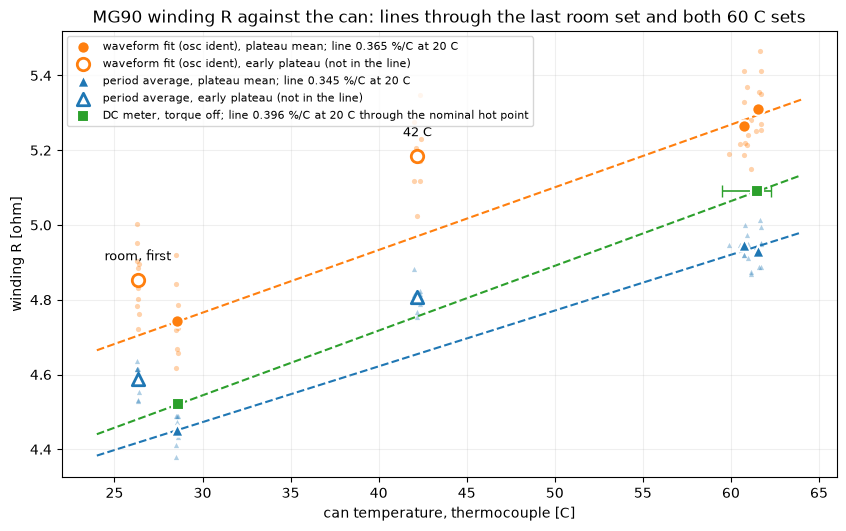

In [6]:
fig, ax = plt.subplots(figsize=(10, 5.8))
tx = np.linspace(24, 64, 50)
STYLE = {"wave_r_ohm": ("tab:orange", "o", "waveform fit (osc ident)"),
         "pa": ("tab:blue", "^", "period average")}
for col, (c, mk, lab) in STYLE.items():
    r = FIT[col]
    ax.plot(tx, r.intercept + r.slope * tx, color=c, lw=1.5, ls="--", zorder=1)
    ax.scatter(B.can_tc, B[col], s=14, color=c, marker=mk, alpha=0.35, lw=0, zorder=2)
    m = B.groupby("plateau")[["can_tc", col]].mean()
    ax.scatter(m.loc[LINE, "can_tc"], m.loc[LINE, col], s=80, color=c, marker=mk, edgecolor="white", lw=1.5,
               zorder=3, label=f"{lab}, plateau mean; line {r.slope / (r.intercept + 20 * r.slope) * 100:.3f} %/C at 20 C")
    ax.scatter(m.loc[EARLY, "can_tc"], m.loc[EARLY, col], s=80, facecolor="white", edgecolor=c, marker=mk, lw=2,
               zorder=3, label=f"{lab}, early plateau (not in the line)")
ax.plot(tx, room.ohm + DC_SLOPE * (tx - T_ROOM), color="tab:green", lw=1.5, ls="--", zorder=1)
ax.scatter([T_ROOM, T_HOT], [room.ohm, hot.ohm], marker="s", s=80, color="tab:green", edgecolor="white", lw=1.5,
           zorder=3, label=f"DC meter, torque off; line {DC_A20:.3f} %/C at 20 C through the nominal hot point")
ax.errorbar([T_HOT], [hot.ohm], xerr=[[T_HOT - T_HOT_LO], [T_HOT_HI - T_HOT]], fmt="none", ecolor="tab:green",
            capsize=4, lw=1.2, zorder=2)
for name in EARLY:
    m = B[B.plateau == name][["can_tc", "wave_r_ohm"]].mean()
    ax.annotate(name, (m.can_tc, m.wave_r_ohm), xytext=(0, 14), textcoords="offset points", ha="center", fontsize=9)
ax.set_xlabel("can temperature, thermocouple [C]")
ax.set_ylabel("winding R [ohm]")
ax.set_title("MG90 winding R against the can: lines through the last room set and both 60 C sets")
ax.grid(alpha=0.2)
ax.legend(fontsize=8, loc="upper left")
plt.show()

**What you are looking at.** R against the can. Small marks are single runs, large marks plateau
means. Filled marks went into the dashed lines, open marks are the first two sets, which did not. The
green squares and their line are the DC meter; the bar on the hot square is the winding's temperature
bracket at that reading.

The three lines run nearly parallel at different levels, the waveform fit about 5% over the meter and
the period average about 1.5% under it. The two open circles are where the story is. Both sit well
above the orange line the later sets define.

## 5. The first two sets

How far over the line are they? Against the burst lines, and against the DC line scaled by the last
room set's pulsed/DC factor, so the answer does not lean on the burst slope. Then the same comparison
for every burst run around the soak, the two cal runs and the four polarity tests, each carried to
28.6 C by copper and held against the last room set. The log has no reading before 14:47, so the
afternoon runs take the 26.4 C it starts at (the can held 26.1 to 26.4 C until 15:00), and the evening
ones the 28.6 C of the room DC reading. Last, the single captures of the two room sets. If what
moved is which rotor angles the bursts happened to catch, the shape of their distribution changes; if
something in series with the winding moved, the whole distribution shifts.

In [7]:
rows = []
for name in EARLY:
    g = B[B.plateau == name]
    t = g.can_tc.mean()
    for col in ("wave_r_ohm", "pa"):
        r = FIT[col]
        pred = r.intercept + r.slope * t
        d = (g[col].mean() / pred - 1) * 100
        se = g[col].std() / np.sqrt(len(g)) / pred * 100
        # the same against the DC line, scaled by the pulsed/DC factor the last room set shows
        f = (r.intercept + r.slope * T_REF) / room.ohm
        d_dc = (g[col].mean() / (f * (room.ohm + DC_SLOPE * (t - T_ROOM))) - 1) * 100
        rows.append({"plateau": name, "R": col, "can C": t, "over the line %": d, "+/-": se,
                     "as C of copper": d / cu_pct(t), "over the DC line %": d_dc})
EXCESS = pd.DataFrame(rows).set_index(["plateau", "R"])
display(EXCESS.round(2))

# The bursts around the soak, the period average per run, carried to 28.6 C by copper and held
# against the last room set's mean the same way. The thermocouple log starts at 14:47 (26.4 C,
# steady to 15:00), so the afternoon runs take 26.4 C; the evening ones take the room DC
# reading's 28.6 C (the log reads 28.6 at 18:45 and the room did not move after).
base_pa = to_ref(B[B.plateau == ORDER[-1]].pa, B[B.plateau == ORDER[-1]].can_tc).mean()
base_wave = to_ref(B[B.plateau == ORDER[-1]].wave_r_ohm, B[B.plateau == ORDER[-1]].can_tc).mean()
rows = []
for x in EX.itertuples():
    pa, n = rs.run_pa(DS.path / x.experiment / x.capture, board)
    t = 26.4 if x.unix < B.unix.min() else 28.6
    rows.append({"time": clock(x.unix).strftime("%H:%M"), "run": x.what, "can C (assumed)": t, "captures": n,
                 "pa R": pa, "pa vs last room set %": (to_ref(pa, t) / base_pa - 1) * 100,
                 "wave R (report)": x.wave_r_ohm,
                 "wave vs last room set %": (to_ref(x.wave_r_ohm, t) / base_wave - 1) * 100})
AROUND = pd.DataFrame(rows).set_index("time")
display(AROUND.round(3))

# Single captures of the two room sets: the period average of every from-rest capture whose phase
# checks out, as quantiles, and the share under 0.9 of the set's median. A brush bridging two
# commutator segments shorts one coil, and such a capture reads about 0.75 of the rest (the one
# osc ident sets aside in most runs).
q = [0.05, 0.25, 0.5, 0.75, 0.95]
first, last = (CAPS[CAPS.plateau == n] for n in (ORDER[0], ORDER[-1]))
qa, qb = np.quantile(first.pa, q), np.quantile(last.pa, q)
print(f"single captures, period average: {len(first)} in the first room set, {len(last)} in the last; share under 0.9 of "
      f"the set's median {np.mean(first.pa < 0.9 * first.pa.median()):.2f} and {np.mean(last.pa < 0.9 * last.pa.median()):.2f}")
print("quantiles 5/25/50/75/95%, first set over last, %: " + ", ".join(f"{v:+.1f}" for v in (qa / qb - 1) * 100)
      + f"; copper for the {last.can_tc.mean() - first.can_tc.mean():.1f} C between them: "
      f"{((K_CU + first.can_tc.mean()) / (K_CU + last.can_tc.mean()) - 1) * 100:+.1f}")


can C  over the line %   +/-  as C of copper  \
plateau     R                                                          
room, first wave_r_ohm  26.33             3.18  0.60            8.30   
            pa          26.33             3.86  0.28           10.08   
42 C        wave_r_ohm  42.20             4.34  0.64           12.00   
            pa          42.20             3.29  0.26            9.11   

                        over the DC line %  
plateau     R                               
room, first wave_r_ohm                3.25  
            pa                        3.98  
42 C        wave_r_ohm                3.94  
            pa                        2.65

,run,can C (assumed),captures,pa R,pa vs last room set %,wave R (report),wave vs last room set %
time,,,,,,,
14:27,"osc cal, first run (its endstop search held at...",26.4,16,4.525,2.504,NaN,NaN
14:35,"osc cal, the run that set the range (held at b...",26.4,16,4.619,4.643,NaN,NaN
14:46,"osc ident burst, polarity test 1",26.4,16,4.559,3.271,NaN,NaN
14:47,"osc ident burst, polarity test 2",26.4,16,4.524,2.483,4.813,2.333
19:02,"osc ident burst, polarity test 3 (hold route)",28.6,16,4.417,-0.774,4.793,1.056
19:03,"osc ident burst, polarity test 4 (hold route)",28.6,16,4.400,-1.158,4.696,-0.989


single captures, period average: 160 in the first room set, 160 in the last; share under 0.9 of the set's median 0.01 and 0.03
quantiles 5/25/50/75/95%, first set over last, %: +2.8, +1.7, +3.1, +2.2, +2.5; copper for the 2.2 C between them: -0.8


**What you are looking at.** Top, each early set's mean over the line in percent, its standard error,
the same in degrees of copper, and against the scaled DC line. Bottom, the runs around the soak.

- **The excess is 3 to 4%, 8 to 12 C.** The first room set reads 3.2% (waveform fit) and 3.9% (period
  average) over its line, the 42 C set 4.3% and 3.3%. Against the DC line it is 2.7 to 4.0%. The
  standard errors are 0.3 to 0.6%, so this is not scatter.
- **It was there during the cal.** By the period average the cal runs at 14:27 and 14:35 read 2.5%
  and 4.6% over the last room set and the polarity tests at 14:46 and 14:47 3.3% and 2.5%. The one
  waveform R from those, polarity test 2, reads 2.3%. Which of a cal run's bursts came before its
  stall and which after is not in the data, so this does not say whether the stalls started it.
- **It was gone in the evening.** The two polarity tests at 19:02 read -0.8% and -1.2% by the period
  average and +1.1% and -1.0% by the fit, the same as the last room set.
- **The whole distribution moved.** Single captures of the first room set sit 1.7 to 3.1% over the
  last set's at every quantile from the 5th to the 95th, where copper says -0.8% for the 2.2 C
  between them. Captures that catch a brush bridging two commutator segments are 1 to 3% of both
  sets. So the excess is not a change in which rotor angles the bursts caught; everything the burst
  sees moved up together.

Two readings could make the first two sets and the rest disagree. Either the first two sets read
high, or the 60 C sets read low. Each has a time signature, and the next cell looks for it inside
the plateaus.

In [8]:
TAU_EXCESS = 720.0                             # s, the decay of R after a heat run on this servo
rows = []
for name in ORDER:
    g = B[B.plateau == name]
    for col in ("wave_r_ohm", "pa"):
        r = stats.linregress((g.unix - g.unix.min()) / 600, g[col] / g[col].mean() * 100)
        rows.append({"plateau": name, "R": col, "trend %/10 min": r.slope, "+/-": r.stderr,
                     "span min": (g.unix.max() - g.unix.min()) / 60})
TREND = pd.DataFrame(rows).set_index(["plateau", "R"])
display(TREND.round(2))
for col in ("wave_r_ohm", "pa"):
    t = TREND.xs(col, level="R")
    w = 1 / t["+/-"] ** 2
    print(f"all five plateaus pooled, {col}: {(w * t['trend %/10 min']).sum() / w.sum():+.2f} "
          f"+/- {1 / np.sqrt(w.sum()):.2f} %/10 min")

# Reading 1, the early sets are high because the winding was still warm from the cal: an excess
# held by heat decays at E / tau. At the size each early set shows, what trend would it put
# inside the set?
print()
for name in EARLY:
    for col in ("wave_r_ohm", "pa"):
        e = EXCESS.loc[(name, col), "over the line %"]
        need = -e * 600 / TAU_EXCESS
        tr_, se = TREND.loc[(name, col), ["trend %/10 min", "+/-"]]
        print(f"warm winding, {name:12s} {col:10s}: a {e:.1f}% excess decaying needs {need:+.2f} %/10 min, "
              f"measured {tr_:+.2f} +/- {se:.2f}, {abs(tr_ - need) / se:.1f} sd apart")

# Reading 2, the 60 C sets are low because the rotor still trailed the can. The shortfall is what
# copper from the first room set predicts at 60 C less what the first 60 C set reads. A rotor
# catching up with tau 720 s climbs at S / tau inside that set, and the second set, about 42 min
# later, sits S (1 - exp(-t / tau)) higher.
print()
a, b, r0 = (B[B.plateau == ORDER[i]] for i in (2, 3, 0))
dt_s = b.unix.mean() - a.unix.mean()
for col in ("wave_r_ohm", "pa"):
    s = (to_ref(r0[col].mean(), r0.can_tc.mean(), a.can_tc.mean()) / a[col].mean() - 1) * 100
    tr_, se = TREND.loc[(ORDER[2], col), ["trend %/10 min", "+/-"]]
    ra, rb = to_ref(a[col], a.can_tc, 61.5), to_ref(b[col], b.can_tc, 61.5)
    d = (rb.mean() / ra.mean() - 1) * 100
    sd = np.hypot(ra.std() / np.sqrt(len(ra)), rb.std() / np.sqrt(len(rb))) / ra.mean() * 100
    step = s * (1 - np.exp(-dt_s / TAU_EXCESS))
    print(f"rotor lag, {col:10s}: shortfall {s:.1f}%; trend in the first 60 C set needs {s * 600 / TAU_EXCESS:+.2f}, "
          f"measured {tr_:+.2f} +/- {se:.2f} %/10 min; second set over the first needs {step:+.1f}%, "
          f"measured {d:+.2f} +/- {sd:.2f}% ({abs(step - d) / sd:.1f} sd apart)")
print(f"the second 60 C set ran {dt_s / 60:.0f} min after the first")

trend %/10 min   +/-  span min
plateau          R                                         
room, first      wave_r_ohm           -1.53  1.97      9.42
                 pa                    0.78  0.90      9.42
42 C             wave_r_ohm            3.37  1.84      9.56
                 pa                    0.31  0.93      9.56
60 C             wave_r_ohm            1.93  1.51      9.49
                 pa                    0.61  0.55      9.49
60 C, second set wave_r_ohm            3.13  1.52      9.48
                 pa                    1.52  0.98      9.48
room, last       wave_r_ohm            0.95  2.05      9.55
                 pa                    0.26  0.90      9.55

all five plateaus pooled, wave_r_ohm: +1.82 +/- 0.78 %/10 min
all five plateaus pooled, pa: +0.65 +/- 0.35 %/10 min

warm winding, room, first  wave_r_ohm: a 3.2% excess decaying needs -2.65 %/10 min, measured -1.53 +/- 1.97, 0.6 sd apart
warm winding, room, first  pa        : a 3.9% excess decaying needs -3.22 %/10 min, measured +0.78 +/- 0.90, 4.5 sd apart
warm winding, 42 C         wave_r_ohm: a 4.3% excess decaying needs -3.61 %/10 min, measured +3.37 +/- 1.84, 3.8 sd apart
warm winding, 42 C         pa        : a 3.3% excess decaying needs -2.74 %/10 min, measured +0.31 +/- 0.93, 3.3 sd apart

rotor lag, wave_r_ohm: shortfall 4.3%; trend in the first 60 C set needs +3.62, measured +1.93 +/- 1.51 %/10 min; second set over the first needs +4.2%, measured +0.56 +/- 0.67% (5.5 sd apart)
rotor lag, pa        : shortfall 5.0%; trend in the first 60 C set needs +4.18, measured +0.61 +/- 0.55 %/10 min; second set over the first needs +4.9%, measured -0.61 +/- 0.33% (16.4 sd apart)
the sec

**What you are looking at.** First, each plateau's runs against time, as a slope in % per 10
minutes, then pooled over all five. Then the two readings, each with the trend or step it predicts
and what was measured.

- **Not a warm winding.** If the first sets were high because the winding still held heat from the
  cal, the excess would decay at the 720 s measured on this servo after a heat run. At 3 to 4%
  that is a fall of 2.7 to 3.6% per 10 minutes inside the set. The period average rules it out at 4.5
  and 3.3 standard errors, and the waveform fit at 3.8 on the 42 C set. On the first room set the
  waveform fit cannot tell (0.6), its scatter is too large for a 10-minute trend. The heat budget points
  the same way. The cal's stalls ran under a second each at 0.18 to 0.24 A, nowhere near enough to
  hold a winding 8 C over its can 14 minutes later.
- **Not the rotor trailing the can.** If the 60 C sets were low because the rotor had not caught up,
  the shortfall would be 4.3% (waveform fit) or 5.0% (period average). R would climb 3.6 to 4.2% per
  10 minutes inside the first 60 C set, and the second set, 42 minutes later, would sit 4.2 to 4.9%
  higher. It sits +0.56 +/- 0.67% and -0.61 +/- 0.33% higher, 5.5 and 16 standard errors from the
  prediction.

So the first two sets read high. The excess held flat through each ten-minute set and through the
hour between them, moved every capture together, and was gone after the 60 C plateau. A binding gear
train, which the first cal's mid-travel stall says was there, does not do this: in a 1 ms burst the
rotor hardly moves, and a rotor that spins up less puts less back-EMF against the drive, so the fit
would read R lower, not higher. What fits is a contact in series with the winding, at the brushes and
commutator or at the J4 motor connector, which was re-plugged that morning, set up by the rebuild,
the stalls or the cal, that relaxed with the heat or with the hours of running. It stays a story
until something separates those, and Open has the experiment.

**One more thing in the table.** Pooled over all five plateaus, R rises inside a set, +1.8 +/- 0.8%
per 10 minutes by the waveform fit and +0.65 +/- 0.35% by the period average. Both are about two
standard errors, and they disagree with each other by a factor of three. Every plateau ran the same
schedule, so it does not move one plateau against another, but it is inside the precision numbers of
section 7. It is listed under Open.

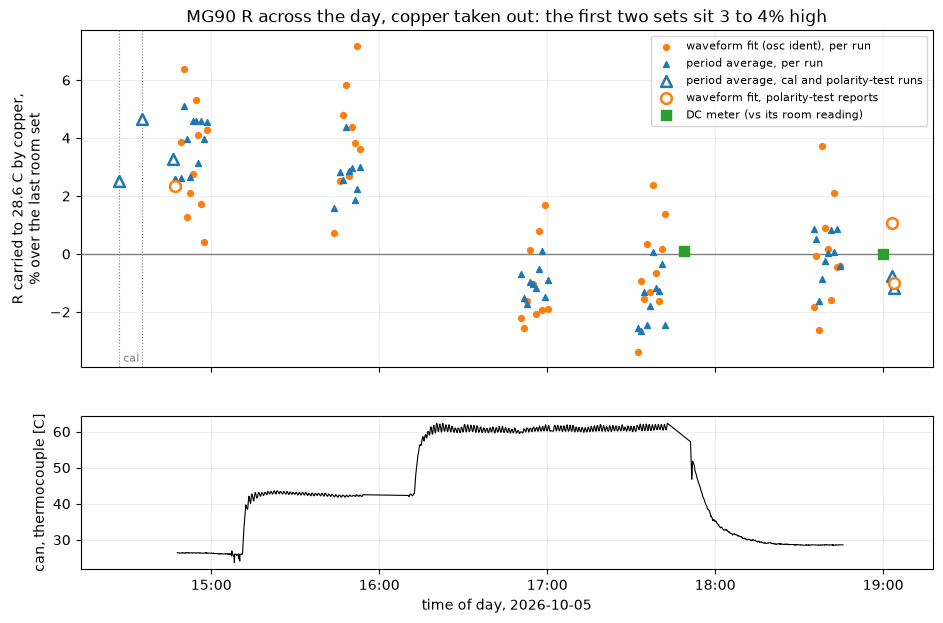

In [9]:
fig, (a1, a2) = plt.subplots(2, 1, figsize=(11, 7), sharex=True, gridspec_kw=dict(height_ratios=[2.2, 1]))
for col, (c, mk, lab) in STYLE.items():
    base = base_wave if col == "wave_r_ohm" else base_pa
    a1.scatter([clock(u) for u in B.unix], (to_ref(B[col], B.can_tc) / base - 1) * 100, s=18, color=c,
               marker=mk, zorder=3, label=f"{lab}, per run")
a1.scatter([clock(u) for u in EX.unix], AROUND["pa vs last room set %"], s=60, facecolor="white",
           edgecolor="tab:blue", marker="^", lw=1.8, zorder=3, label="period average, cal and polarity-test runs")
ok = AROUND["wave vs last room set %"].notna().to_numpy()
a1.scatter([clock(u) for u in EX.unix[ok]], AROUND["wave vs last room set %"][ok], s=60, facecolor="white",
           edgecolor="tab:orange", marker="o", lw=1.8, zorder=3, label="waveform fit, polarity-test reports")
a1.scatter([clock(u) for u in DC.unix], (to_ref(DC.ohm, [T_HOT if o == hot.ohm else T_ROOM for o in DC.ohm])
           / room.ohm - 1) * 100, marker="s", s=60, color="tab:green", zorder=3, label="DC meter (vs its room reading)")
a1.axhline(0, color="grey", lw=1)
for x in EX[EX.experiment == "cal"].itertuples():
    a1.axvline(clock(x.unix), color="grey", lw=0.8, ls=":")
a1.text(clock(EX.unix.iloc[0]), a1.get_ylim()[0] * 0.95, " cal", fontsize=8, color="grey")
a1.set_ylabel("R carried to 28.6 C by copper,\n% over the last room set")
a1.legend(fontsize=8, loc="upper right")
a1.grid(alpha=0.2)
a1.set_title("MG90 R across the day, copper taken out: the first two sets sit 3 to 4% high")
a2.plot([clock(u) for u in LOG.unix], LOG.can_c, color="k", lw=0.8)
a2.set_ylabel("can, thermocouple [C]")
a2.set_xlabel("time of day, 2026-10-05")
a2.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M", tz=PDT))
a2.grid(alpha=0.2)
plt.show()

**What you are looking at.** Top, every run's R carried to 28.6 C by copper, in percent over the last
room set's mean, for the waveform fit and the period average, with the cal and polarity-test runs as
open marks and the DC readings as squares (each against the room DC reading). The dotted lines are
the two cal runs. Bottom, the thermocouple.

With copper taken out, a perfect thermometer would put every point on the zero line. The first two
sets sit 2 to 4% up, with the cal and polarity runs before them. Both 60 C sets sit 1 to 1.5% under
zero, where the DC hot point sits on it. That is the compression from section 4, and section 6 puts a
number on it. The last room set and the evening polarity tests are back on zero.

## 6. Pulsed against DC

The burst routes read a different R than the meter, which is no surprise. The burst sees the winding
with 0.4 A flowing and the rotor starting to turn, through the bridge and the amplifier's settling;
the meter sees it standing still at a milliamp, at whatever angle the commutator stopped. For a
thermometer on copper's slope the level does not matter. What matters is whether the ratio changes
with temperature, because a ratio that falls is a burst R that scales with the winding's R less than
one to one, and from a room reference that reads hot windings cool. Here it is at room (the last room
set against 4.52 ohm) and hot (both 60 C sets against 5.09 ohm), each burst run first carried to the
meter's temperature by copper.

The hot reading's bracket from section 4 does not rescue a falling ratio. If the winding was cooler
than 61.5 C at the reading, the hot bursts carried to that temperature read lower still, and the
ratio falls more. Only a winding hotter than the can ever read would raise it. So the bracket can
only make the compression bigger, and the errors below leave it out.

Then what each of the two quieter routes leans on. The period average holds $L$ at 0.81 mH, and its
R is linear in $L$, so the R each capture would give with the run's own fitted $L$ follows from the
share the $L$ term carried. The V0-projected fit moves every run to one $V_0$, so it matters where
each plateau's runs landed. And the period average's 25% rung against its 40% rung, a level check.


In [10]:
rows = []
for col in ("wave_r_ohm", "wave_v0", "pa"):
    g = B[B.plateau == ORDER[-1]]
    rm = to_ref(g[col], g.can_tc, T_ROOM)
    h = B[B.plateau.isin(ORDER[2:4])]
    hm = to_ref(h[col], h.can_tc, T_HOT)
    f_room, f_hot = rm.mean() / room.ohm, hm.mean() / hot.ohm
    # the run scatter and one digit on the meter; the hot reading's temperature bracket is one-sided
    # and left out (section 6 text)
    e_room = np.hypot(rm.std() / np.sqrt(len(rm)) / rm.mean(), 0.005 / room.ohm) * 100
    e_hot = np.hypot(hm.std() / np.sqrt(len(hm)) / hm.mean(), 0.005 / hot.ohm) * 100
    rows.append({"R": col, "pulsed/DC at room": f_room, "+/- %": e_room, "pulsed/DC hot": f_hot, "+/- % ": e_hot,
                 "hot over room %": (f_hot / f_room - 1) * 100, "+/-": np.hypot(e_room, e_hot)})
RATIO = pd.DataFrame(rows).set_index("R")
display(RATIO.round(4))
print("a ratio falling c% over 33 C reads a 60 C winding low by c / {:.3f} C: ".format(cu_pct(60))
      + ", ".join(f"{c:.1f}% -> {c / cu_pct(60):.1f} C" for c in (0.9, 1.4, 2.0)))

# (1) The period average with the run's fitted L instead of 0.81 mH: pa is linear in L, and
# l_share is the part of pa the L term carried, so pa(L') = pa (1 - l_share (L'/L - 1)).
CAPS["pa_fit_l"] = CAPS.pa * (1 - CAPS.l_share * (CAPS.l_mh * 1e-3 / rs.L_H - 1))
B["pa_fit_l"] = [CAPS[(CAPS.plateau == x.plateau) & (CAPS.k == x.k)].pa_fit_l.median() for x in B.itertuples()]
print(f"\nthe L term carries {CAPS.l_share.mean() * 100:.0f}% of the period-average R; osc ident's fitted L by plateau, mH: "
      + ", ".join(f"{n} {v:.3f}" for n, v in B.groupby("plateau", sort=False).l_mh.mean().items()))
ln = B[B.plateau.isin(LINE)]
for col, lab in (("pa", "L held at 0.81 mH"), ("pa_fit_l", "L the run's fitted value")):
    r = stats.linregress(ln.can_tc, ln[col])
    a20 = r.slope / (r.intercept + 20 * r.slope) * 100
    print(f"period average, {lab:26s}: {a20:.3f} +/- {r.stderr / (r.intercept + 20 * r.slope) * 100:.3f} %/C at 20 C, "
          f"{a20 / cu_pct(20) * 100:.0f}% of copper")

# (2) Where each plateau's runs landed on V0, and how far the projection moved each plateau's mean.
pm = B.groupby("plateau", sort=False).agg(v0=("v0_v", "mean"), v0_se=("v0_v", "sem"), wave=("wave_r_ohm", "mean"),
                                           wave_v0=("wave_v0", "mean"))
pm["projection moved the mean %"] = (pm.wave_v0 / pm.wave - 1) * 100
print("\nV0 per plateau and what the projection did to its mean:")
display(pm.round(3))

# (3) The period average's 25% rung against its 40% rung, per plateau.
print("period average, 25% rung over 40% rung, %: " + ", ".join(
    f"{n} {(g[g.duty == 25].pa.median() / g[g.duty == 40].pa.median() - 1) * 100:+.1f}"
    for n, g in CAPS.groupby("plateau", sort=False)))


,pulsed/DC at room,+/- %,pulsed/DC hot,+/- %,hot over room %,+/-
R,,,,,,
wave_r_ohm,1.0493,0.5791,1.0400,0.3515,-0.8884,0.6775
wave_v0,1.0522,0.2309,1.0366,0.1846,-1.4829,0.2957
pa,0.9849,0.2685,0.9712,0.2055,-1.3839,0.3381


a ratio falling c% over 33 C reads a 60 C winding low by c / 0.340 C: 0.9% -> 2.7 C, 1.4% -> 4.1 C, 2.0% -> 5.9 C

the L term carries 17% of the period-average R; osc ident's fitted L by plateau, mH: room, first 0.786, 42 C 0.811, 60 C 0.829, 60 C, second set 0.831, room, last 0.798
period average, L held at 0.81 mH         : 0.345 +/- 0.011 %/C at 20 C, 88% of copper
period average, L the run's fitted value  : 0.322 +/- 0.011 %/C at 20 C, 82% of copper

V0 per plateau and what the projection did to its mean:


,v0,v0_se,wave,wave_v0,projection moved the mean %
plateau,,,,,
"room, first",-0.200,0.014,4.854,4.869,0.318
42 C,-0.234,0.012,5.186,5.135,-0.971
60 C,-0.201,0.010,5.265,5.278,0.245
"60 C, second set",-0.233,0.014,5.309,5.261,-0.901
"room, last",-0.201,0.016,4.742,4.755,0.273


period average, 25% rung over 40% rung, %: room, first -3.4, 42 C -4.5, 60 C -4.4, 60 C, second set -4.3, room, last -3.8


**What you are looking at.** Top, the pulsed R over the DC R at each end, with errors from the run
scatter and the meter's digit, and how much the ratio moves from room to 60 C, then what a fall of
that size means in degrees at 60 C. Below, the three checks: the fitted $L$ by plateau and the period
average's slope with $L$ held against $L$ followed; the $V_0$ each plateau landed on and how far the
projection moved its mean; the period average's 25% rung against its 40%.

- **Plain waveform fit.** 1.049 at room, 1.040 hot, -0.9 +/- 0.7%. On its own that is a constant
  factor within its error, which a ratio thermometer divides out.
- **The quieter two agree on a fall of 1.4 to 1.5 +/- 0.3%**, 4 to 5 standard errors, but neither
  is independent evidence at this level. The period average holds $L$ at 0.81 mH while the $L$ term
  carries about 17% of its R; `osc ident`'s fitted $L$ rises from 0.79 mH at room to 0.83 at 60 C,
  and following it moves the period average's slope from 0.345 to 0.322 %/C, a swing as large as the
  effect. The V0-projected fit moves every run to one $V_0$, and the plateaus did not land on one: the
  42 C set and the second 60 C set sit 0.03 V more negative than the other three, about 2.5 of their
  standard errors, so the projection shifted those two means about 1% against the rest. Whether that
  $V_0$ wander is the fit's noise or the brushes is exactly what is unknown. And the period average
  reads the 25% rung 3.4 to 4.5% under the 40% rung at every plateau, so it carries level
  systematics of a few percent that happen to be steady across the day.

So the data supports a compression of the burst's R scale against DC of 0 to 2% over 33 C, with the
sign probably negative. It is not a slope for the thermometer to fit. If it is the 1.4% the quieter
routes say and nothing corrects it, a 60 C winding reads about 4 C low from a room reference, inside
the 5 C target but most of it. Section 7 shows that in degrees, and Open has the experiment that
would pin it.


## 7. The thermometer

With the winding loop copper and the pulsed factor constant to a percent or two, the thermometer is
copper's handbook line, nothing fitted, through one reference reading $R_{ref}$ taken at a known
$T_{ref}$:

$$T = T_{ref} + \left(\frac{R}{R_{ref}} - 1\right)(234.5 + T_{ref})$$

How well it reads depends on how much one run scatters at a fixed temperature. That is the pooled
scatter of every run around its own plateau's mean, with the degrees of freedom the five means took
out. Then the formula on every run, with $R_{ref}$ from the last room set, for the plain and the
V0-projected waveform fit.

In [11]:
rows = []
for col in ("wave_r_ohm", "wave_v0", "pa"):
    rel = B[col] / B.groupby("plateau")[col].transform("mean") - 1
    sd = np.sqrt((rel ** 2).sum() / (len(B) - B.plateau.nunique())) * 100
    rows.append({"R": col, "one run sd %": sd, "C at 28.6": sd / cu_pct(28.6), "C at 60": sd / cu_pct(60),
                 "ten runs sd %": sd / np.sqrt(10), "C at 28.6 ": sd / np.sqrt(10) / cu_pct(28.6)})
PREC = pd.DataFrame(rows).set_index("R")
display(PREC.round(2))

# The formula on every plateau's mean, R_ref the last room set's mean at its own can, for the
# plain waveform fit and the V0-projected one.
g = B[B.plateau == ORDER[-1]]
T_R = g.can_tc.mean()
rows = []
for name in ORDER:
    g = B[B.plateau == name]
    row = {"plateau": name, "can C": g.can_tc.mean()}
    for col in ("wave_r_ohm", "wave_v0"):
        r_ref = B[B.plateau == ORDER[-1]][col].mean()
        t = T_R + (g[col] / r_ref - 1) * (K_CU + T_R)        # every run through the formula
        row[f"{col}: from R, mean C"] = t.mean()
        row[f"{col}: error C"] = t.mean() - g.can_tc.mean()
        row[f"{col}: one run sd C"] = t.std()
    rows.append(row)
display(pd.DataFrame(rows).set_index("plateau").round(1))
print(f"T_ref {T_R:.2f} C; R_ref {B[B.plateau == ORDER[-1]].wave_r_ohm.mean():.3f} ohm (plain), "
      f"{B[B.plateau == ORDER[-1]].wave_v0.mean():.3f} ohm (V0 projected)")

,one run sd %,C at 28.6,C at 60,ten runs sd %,C at 28.6
R,,,,,
wave_r_ohm,1.76,4.62,5.17,0.56,1.46
wave_v0,0.68,1.80,2.01,0.22,0.57
pa,0.81,2.14,2.39,0.26,0.68


,can C,"wave_r_ohm: from R, mean C",wave_r_ohm: error C,wave_r_ohm: one run sd C,"wave_v0: from R, mean C",wave_v0: error C,wave_v0: one run sd C
plateau,,,,,,,
"room, first",26.3,34.7,8.4,4.9,34.9,8.5,1.7
42 C,42.2,53.2,11.0,5.3,49.6,7.4,2.1
60 C,60.7,57.5,-3.2,4.4,57.5,-3.2,1.9
"60 C, second set",61.5,60.0,-1.5,5.0,56.6,-5.0,2.1
"room, last",28.6,28.6,0.0,5.0,28.6,0.0,1.8


T_ref 28.56 C; R_ref 4.742 ohm (plain), 4.755 ohm (V0 projected)


**What you are looking at.** Top, one run's scatter in percent and in degrees at 28.6 and 60 C, and the
same for the mean of ten runs. Bottom, the formula on each plateau's runs, the mean and its error
against the thermocouple, and one run's spread, with the last room set as the reference.

- **Precision.** One plain waveform-fit run scatters 1.76%, 4.6 C at room and 5.2 C at 60 C. Ten
  average to 0.56%, 1.5 C. So one run sits at the 5 C target and ten are well inside it. With the
  R-V0 trade projected out one run is 0.68%, 1.8 C, about what notebook 02 sec 22 finds at rest. The
  trade's slope came from these same runs, so that number is a little optimistic. These all include
  the within-set rise from section 5.
- **Accuracy against the thermocouple.** From the last room set, the 60 C sets read 3.2 and 1.5 C
  low by the plain fit and 3.2 and 5.0 C low with V0 projected. That is section 6's compression in
  degrees, 1 to 1.7% of R. The first two sets read 7 to 11 C high, the contact excess of section 5,
  twice the budget.

**What the firmware has to do.** The reference is the whole game. A rested winding at a known
temperature gives $R_{ref}$, and from then on a ratio tracks the winding to a few C. But a contact
shift of 4% that nothing announces reads as 10 C, and this one lasted at least an hour after a
rebuild, three stalls and a cal. So:

- re-baseline $R_{ref}$ at power-up, at rest, after the servo has sat idle for an hour or more, at a
  known temperature. The board NTC can supply that temperature (the open "NTC returns as the ambient
  reference" item), since a board and a motor that have both sat for an hour are both at ambient,
- re-baseline after any cal, stall or rebuild, and distrust R for hours after one, until the heat
  against time question in Open is answered,
- take $R_{ref}$ as the mean of several runs, not one, since one plain run carries 4.6 C,
- keep copper's slope. A fitted per-servo coefficient would bake the burst's own compression and the
  contact state of the day into the thermometer; if the compression is confirmed it is a correction
  to the burst estimator, applied once for the estimator, not a slope,
- and have `osc ident` hold or project V0. It is worth a factor of 2.5 in precision.

## Caveats

- **One motor, one day.** One MG90, with its gear train rebuilt that morning. Another motor's
  contact behaviour could be better or worse, and contact is the part of R that moved.
- **The hot DC reading's temperature is a bracket, not a number.** The one meter reads either the
  thermocouple or ohms, so the log has a gap at both DC readings. The room reading sits between two
  28.6 C readings. The hot one came six minutes after the second 60 C set with the dryer coming off
  temperature; the can at that moment is anywhere from the mid 50s to 62 C, and the winding behind
  the air gap 59.5 to 62.3 C. Every DC number in section 4 carries that bracket, and the pulsed/DC ratio of
  section 6 can only fall further inside it.
- **The thermocouple bead is on the can, in hot air.** Taped to the outside of the can in a dryer that
  blows 60 C air, it may read a little closer to the air than the winding inside. That bias is common
  to the hot bursts and the hot DC reading, so it cancels in their ratio and only stretches the DC
  slope.
- **The meter is not graded.** B41T+, 220 ohm range, 0.01 ohm a digit, rated 0.5% plus 10 digits.
  Both readings on one range, so the 0.5% cancels in the ratio and the 10 digits are a zero common to
  both, in the fixed part only. Whether the probe leads were nulled is not recorded; an unnulled pair
  is 0.05 to 0.1 ohm and would also land in the fixed part, where the pair leaves no room for one.
- **One DC reading per temperature, at one rotor angle.** A three-slot motor's terminal resistance
  depends on where the commutator stopped: with a brush bridging two segments one coil is shorted and
  the reading drops about a quarter, which is what the captures `osc ident` sets aside show. Both
  readings sitting on copper's ratio to 0.1% says they sat on the same part of the cycle, but the
  level, and so the pulsed/DC factor of 1.04 to 1.05, is one angle's.
- **The early runs' temperatures are assumed.** The cal and the first polarity tests ran before the
  log started and take its first reading, 26.4 C. The room held 26.1 to 26.4 C for the next 13
  minutes, so a degree is the most that could be off, small against 3%.
- **The levels are the estimators' own.** The waveform fit reads 5% over the meter and the period
  average 1.5% under it. The thermometer only uses ratios, so neither level matters here.

## Open

- **Heat, hours or which contact, for the morning excess (section 5).** It was gone after the 60 C
  plateau, which was also an hour and a half later. Candidates: (a) the heat relaxed the brush
  contact (spring set, a film on the commutator), (b) running and time alone did, (c) the J4 motor
  connector, re-plugged that morning, settled, (d) it was in the static winding path and a meter
  would have seen it too. The test is a provoked repeat. Stall the output at a stop and recalibrate,
  then (A) hold the servo at room for three hours with a burst run every 15 minutes, and (B) on
  another day, heat to 60 C straight after the cal and come back. (a) predicts the excess holds
  through A and clears in B, (b) predicts it decays in A. A meter reading straight after the cal and
  again at the end, once across J4 and once at the motor's own tabs, separates (c) and (d): a
  connector shows in the J4 reading and not at the tabs, a brush film in both, and a reading that
  tracks the bursts puts it in the static path.
- **The burst's R scale against DC, 0 to 2% over 33 C (sections 4 and 6).** This dataset cannot
  resolve it: the hot DC point is one reading at a bracketed temperature, and the two quiet routes
  each lean on a temperature-correlated choice. The experiment that can is a pulsed-against-DC pair
  at one steady temperature, with no carry. Hold the dryer at a plateau and alternate burst runs
  with meter readings across J4, three readings at different rest angles each time, leads nulled,
  the can on a second instrument (the board's NTC channel on the can, repaired, or a second meter) so
  the log never breaks. At room and at 60 C that gives the ratio at each end directly, and a ratio
  that differs by more than its scatter (about 0.3% a pair) is the compression, whatever the hot
  point's temperature. Then the cause. (a) A burst error that moves with the current, which is 7%
  lower hot: the same runs at 7.9 V and 7.0 V on the supply at room drop the current 11% with no
  heat, and (a) predicts R moves about 1% with the rail. (b) The brush drop $V_0$ changing with
  temperature, which the plain fit absorbs and the period average cannot: the pair above with both
  routes side by side separates it. (c) $L$, already tested offline here: the fitted $L$ rises 5% and
  moves the period average by the whole effect, but the plain fit has $L$ free, so (c) cannot explain
  the plain fit's fall.
- **R rising inside every set (section 5).** +1.8 +/- 0.8% per 10 minutes by the waveform fit and
  +0.65 +/- 0.35% by the period average. Candidates: (a) the runs heat the winding themselves, since
  each drives the motor near the current limit for about 20 s once a minute, (b) a drift on the board
  over the plateau. The same ten runs spaced five minutes apart separate them. (a) predicts the rise
  per minute falls about five times, (b) predicts it does not change. The two estimators disagreeing
  by a factor of three is part of the same question.
- **The loaded-servo heating curve.** Everything here is a rested motor at a temperature the dryer
  imposed. The next thermal step is a two-node model with a real load, on the torque rig
  with no dryer, with copper's slope as the thermometer.
